# Instacart Customer Segmentation - Standard K-Means

Using traditional k-means clustering with optimal k selection via:
- **Elbow Method**: Find the "elbow" in inertia curve
- **Silhouette Score**: Measure cluster quality and separation
- **PCA Visualization**: 2D projection of high-dimensional clusters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load Instacart User Features Dataset

In [2]:
# Load the feature matrix
data_path = r"c:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\8th exploration instacart\instacart_user_features.csv"
df = pd.read_csv(data_path)

print("="*80)
print("INSTACART USER FEATURES DATASET")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Users: {len(df):,}")
print(f"Features: {len(df.columns)-1} (excluding user_id)")
print(f"\nFirst few rows:")
df.head()

INSTACART USER FEATURES DATASET
Shape: (206209, 37)
Users: 206,209
Features: 36 (excluding user_id)

First few rows:


,user_id,total_orders,avg_days_between_orders,avg_basket_size,reorder_rate,total_products_purchased,unique_products,preferred_day_of_week,preferred_hour_of_day,day_consistency,...,dept_pct_household,dept_pct_international,dept_pct_meat_seafood,dept_pct_missing,dept_pct_other,dept_pct_pantry,dept_pct_personal_care,dept_pct_pets,dept_pct_produce,dept_pct_snacks
0,1,10,19.555556,5.900000,0.694915,59,18,1,7,1.269296,...,0.033898,0.000000,0.000000,0.0,0.0,0.016949,0.000000,0.0,0.084746,0.372881
1,2,14,15.230769,13.928571,0.476923,195,102,1,10,1.231456,...,0.000000,0.015385,0.005128,0.0,0.0,0.056410,0.005128,0.0,0.184615,0.215385
2,3,12,12.090909,7.333333,0.625000,88,33,0,16,1.311372,...,0.011364,0.000000,0.000000,0.0,0.0,0.045455,0.000000,0.0,0.431818,0.102273
3,4,5,13.750000,3.600000,0.055556,18,17,4,11,0.836660,...,0.111111,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.111111,0.055556
4,5,4,13.333333,9.250000,0.378378,37,23,3,18,1.500000,...,0.000000,0.054054,0.000000,0.0,0.0,0.054054,0.000000,0.0,0.513514,0.027027


In [3]:
# Prepare features
user_ids = df['user_id'].values
feature_columns = [col for col in df.columns if col != 'user_id']
X_raw = df[feature_columns].values

# Standardize features (important for k-means)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Feature Matrix Preparation:")
print(f"  Users: {X.shape[0]:,}")
print(f"  Features: {X.shape[1]}")
print(f"  Standardized: Mean ≈ {X.mean():.6f}, Std ≈ {X.std():.6f}")
print("\n✓ Data ready for k-means clustering")

Feature Matrix Preparation:
  Users: 206,209
  Features: 36
  Standardized: Mean ≈ 0.000000, Std ≈ 1.000000

✓ Data ready for k-means clustering


## Elbow Method - Finding Optimal K

The elbow method plots inertia (sum of squared distances to nearest cluster center) for different values of k. The "elbow" point indicates a good trade-off between number of clusters and clustering quality.

In [4]:
# Test k values from 2 to 15
k_range = range(2, 16)
inertias = []
silhouette_scores = []

print("Computing k-means for different k values...")
print("This may take a few minutes...\n")

for k in k_range:
    print(f"Testing k={k}...", end=" ")
    
    # Fit k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X)
    
    # Calculate metrics
    inertia = kmeans.inertia_
    silhouette_avg = silhouette_score(X, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette_avg)
    
    print(f"Inertia: {inertia:,.0f}, Silhouette: {silhouette_avg:.4f}")

print("\n✓ Completed k-means evaluation for all k values")

Computing k-means for different k values...
This may take a few minutes...

Testing k=2... Inertia: 6,646,643, Silhouette: 0.0944
Testing k=3... Inertia: 6,365,823, Silhouette: 0.0776
Testing k=4... Inertia: 6,162,566, Silhouette: 0.0440
Testing k=5... Inertia: 5,995,417, Silhouette: 0.0467
Testing k=6... Inertia: 5,848,944, Silhouette: 0.0490
Testing k=7... Inertia: 5,706,683, Silhouette: 0.0546
Testing k=8... Inertia: 5,607,366, Silhouette: 0.0534
Testing k=9... Inertia: 5,495,629, Silhouette: 0.0584
Testing k=10... Inertia: 5,412,944, Silhouette: 0.0588
Testing k=11... Inertia: 5,339,285, Silhouette: 0.0434
Testing k=12... Inertia: 5,224,176, Silhouette: 0.0426
Testing k=13... Inertia: 5,121,461, Silhouette: 0.0451
Testing k=14... Inertia: 5,050,494, Silhouette: 0.0506
Testing k=15... Inertia: 4,978,253, Silhouette: 0.0510

✓ Completed k-means evaluation for all k values


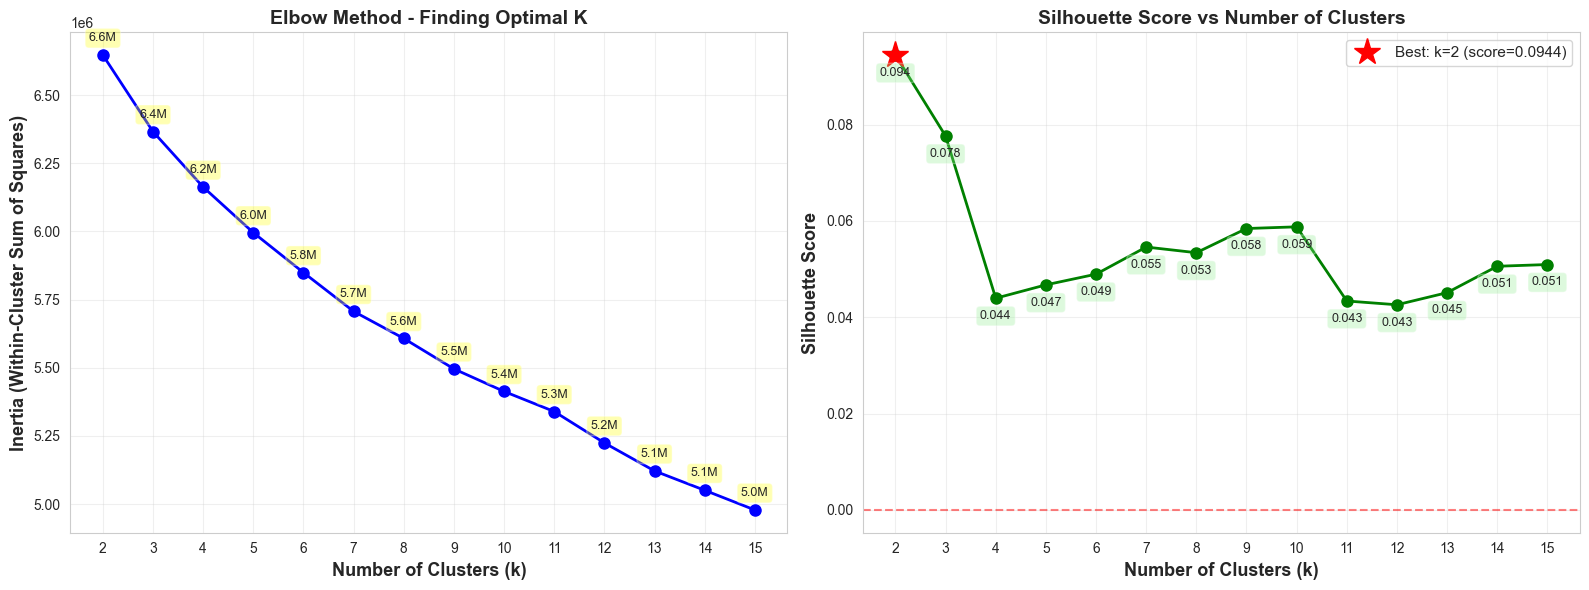


OPTIMAL K ANALYSIS
Best k by Silhouette Score: 2 (score: 0.0944)

Recommendation: Look for the 'elbow' in the inertia plot
Consider k values around: 1 to 3


In [5]:
# Visualize Elbow Method and Silhouette Scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method (Inertia)
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=13, fontweight='bold')
ax1.set_title('Elbow Method - Finding Optimal K', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Add annotations for the inertia values
for k, inertia in zip(k_range, inertias):
    ax1.annotate(f'{inertia/1e6:.1f}M', 
                 xy=(k, inertia), 
                 xytext=(0, 10), 
                 textcoords='offset points',
                 ha='center', 
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Highlight best silhouette score
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)
ax2.plot(best_k_silhouette, best_silhouette, 'r*', markersize=20, 
         label=f'Best: k={best_k_silhouette} (score={best_silhouette:.4f})')
ax2.legend(fontsize=11)

# Add annotations for silhouette scores
for k, score in zip(k_range, silhouette_scores):
    ax2.annotate(f'{score:.3f}', 
                 xy=(k, score), 
                 xytext=(0, -15), 
                 textcoords='offset points',
                 ha='center', 
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("OPTIMAL K ANALYSIS")
print("="*80)
print(f"Best k by Silhouette Score: {best_k_silhouette} (score: {best_silhouette:.4f})")
print(f"\nRecommendation: Look for the 'elbow' in the inertia plot")
print(f"Consider k values around: {best_k_silhouette-1} to {best_k_silhouette+1}")

## Run K-Means with Optimal K

Based on the analysis above, select the optimal k and perform final clustering.

In [6]:
# Use the best k from silhouette score
optimal_k = best_k_silhouette

print(f"Running k-means with optimal k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
final_labels = kmeans_final.fit_predict(X)

# Calculate final metrics
final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X, final_labels)

print("\n" + "="*80)
print(f"FINAL K-MEANS CLUSTERING RESULTS (k={optimal_k})")
print("="*80)
print(f"Inertia: {final_inertia:,.0f}")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"\nCluster Distribution:")

# Show cluster sizes
unique_labels, counts = np.unique(final_labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    percentage = (count / len(final_labels)) * 100
    print(f"  Cluster {label}: {count:,} users ({percentage:.2f}%)")

print("="*80)

Running k-means with optimal k=2...

FINAL K-MEANS CLUSTERING RESULTS (k=2)
Inertia: 6,646,643
Silhouette Score: 0.0944

Cluster Distribution:
  Cluster 0: 144,864 users (70.25%)
  Cluster 1: 61,345 users (29.75%)


## Cluster Visualization with PCA

Use PCA to reduce the high-dimensional data to 2D for visualization.

Performing PCA to reduce dimensions to 2D...
Explained variance ratio: [0.16127386 0.07063421]
Total variance explained: 23.19%


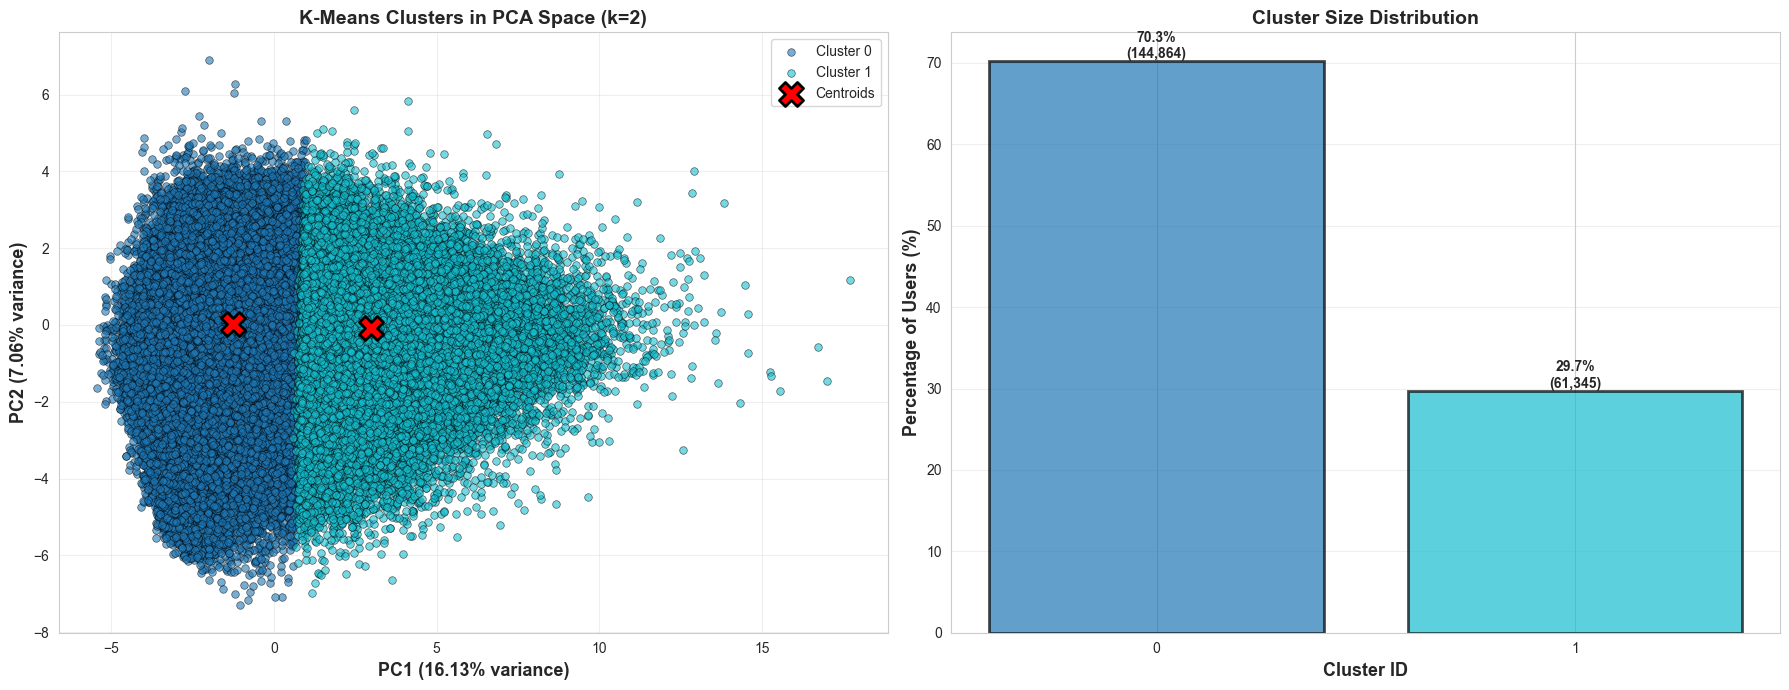

In [7]:
# Perform PCA for visualization
print("Performing PCA to reduce dimensions to 2D...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Scatter plot of clusters
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    mask = final_labels == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=[colors[i]], label=f'Cluster {i}', 
               alpha=0.6, s=30, edgecolors='k', linewidth=0.5)

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', 
           linewidth=2, label='Centroids', zorder=10)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=13, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=13, fontweight='bold')
ax1.set_title(f'K-Means Clusters in PCA Space (k={optimal_k})', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Cluster size distribution
cluster_sizes = [np.sum(final_labels == i) for i in range(optimal_k)]
cluster_percentages = [(size / len(final_labels)) * 100 for size in cluster_sizes]

bars = ax2.bar(range(optimal_k), cluster_percentages, color=colors, 
               edgecolor='black', linewidth=2, alpha=0.7)
ax2.set_xlabel('Cluster ID', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percentage of Users (%)', fontsize=13, fontweight='bold')
ax2.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
ax2.set_xticks(range(optimal_k))
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, cluster_percentages)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%\n({cluster_sizes[i]:,})',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Silhouette Analysis per Cluster

Detailed silhouette analysis showing the quality of each cluster. Values close to 1 indicate well-separated clusters.

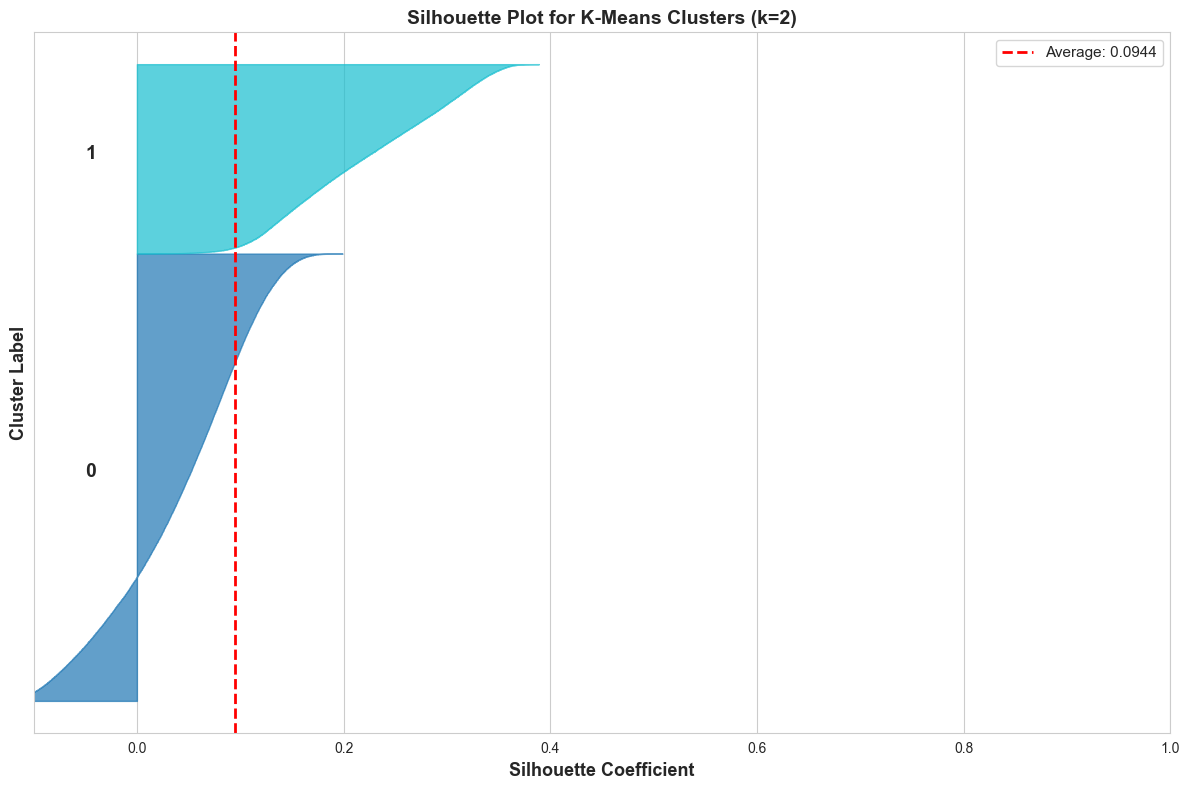


PER-CLUSTER SILHOUETTE SCORES
Cluster 0: 0.0408 (size: 144,864)
Cluster 1: 0.2212 (size: 61,345)

Overall Average: 0.0944


In [8]:
# Calculate silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X, final_labels)

# Create silhouette plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    # Get silhouette scores for samples in this cluster
    cluster_silhouette_values = sample_silhouette_values[final_labels == i]
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_silhouette_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    
    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), 
            fontsize=14, fontweight='bold')
    
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10

ax.set_title(f'Silhouette Plot for K-Means Clusters (k={optimal_k})', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient', fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster Label', fontsize=13, fontweight='bold')

# The vertical line for average silhouette score of all the values
ax.axvline(x=final_silhouette, color="red", linestyle="--", linewidth=2,
           label=f'Average: {final_silhouette:.4f}')
ax.legend(fontsize=11)

ax.set_yticks([])
ax.set_xlim([-0.1, 1])
plt.tight_layout()
plt.show()

# Print per-cluster silhouette scores
print("\n" + "="*80)
print("PER-CLUSTER SILHOUETTE SCORES")
print("="*80)
for i in range(optimal_k):
    cluster_silhouette_values = sample_silhouette_values[final_labels == i]
    cluster_avg = cluster_silhouette_values.mean()
    print(f"Cluster {i}: {cluster_avg:.4f} (size: {len(cluster_silhouette_values):,})")
print(f"\nOverall Average: {final_silhouette:.4f}")
print("="*80)

## Cluster Profiling - Understanding Customer Segments

Analyze the characteristics of each cluster by examining feature means.

In [9]:
# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = final_labels

# Calculate mean values for each cluster (unstandardized data for interpretation)
cluster_profiles = df_clustered.groupby('cluster')[feature_columns].mean()

# Display key behavioral features
key_features = [
    'total_orders', 'avg_days_between_orders', 'avg_basket_size', 
    'reorder_rate', 'unique_products', 'unique_departments',
    'preferred_day_of_week', 'preferred_hour_of_day'
]

print("\n" + "="*80)
print("CLUSTER PROFILES - KEY BEHAVIORAL FEATURES")
print("="*80)
print("\nCluster Characteristics:")
print(cluster_profiles[key_features].round(2))

# Find top defining features for each cluster (using standardized data)
print("\n" + "="*80)
print("TOP DEFINING FEATURES PER CLUSTER (Z-Scores)")
print("="*80)

for cluster_id in range(optimal_k):
    cluster_mask = final_labels == cluster_id
    cluster_data = X[cluster_mask]
    
    # Calculate mean z-scores for this cluster
    cluster_mean = cluster_data.mean(axis=0)
    
    # Get top features by absolute z-score
    top_indices = np.argsort(np.abs(cluster_mean))[-5:][::-1]
    
    print(f"\nCluster {cluster_id} (n={cluster_mask.sum():,}):")
    for idx in top_indices:
        feature_name = feature_columns[idx]
        z_score = cluster_mean[idx]
        direction = "High" if z_score > 0 else "Low"
        print(f"  {direction:4s} {feature_name:40s} (z={z_score:+.2f})")


CLUSTER PROFILES - KEY BEHAVIORAL FEATURES

Cluster Characteristics:
         total_orders  avg_days_between_orders  avg_basket_size  reorder_rate  \
cluster                                                                         
0                8.40                    17.33             8.51          0.36   
1               32.58                    10.20            13.35          0.61   

         unique_products  unique_departments  preferred_day_of_week  \
cluster                                                               
0                  37.46                9.39                   2.05   
1                 128.48               14.22                   2.13   

         preferred_hour_of_day  
cluster                         
0                        11.95  
1                        12.72  

TOP DEFINING FEATURES PER CLUSTER (Z-Scores)

Cluster 0 (n=144,864):
  Low  unique_products                          (z=-0.48)
  Low  unique_aisles                            (z=-0.46)
  

## Department Preferences by Cluster

Visualize which departments each customer segment prefers.

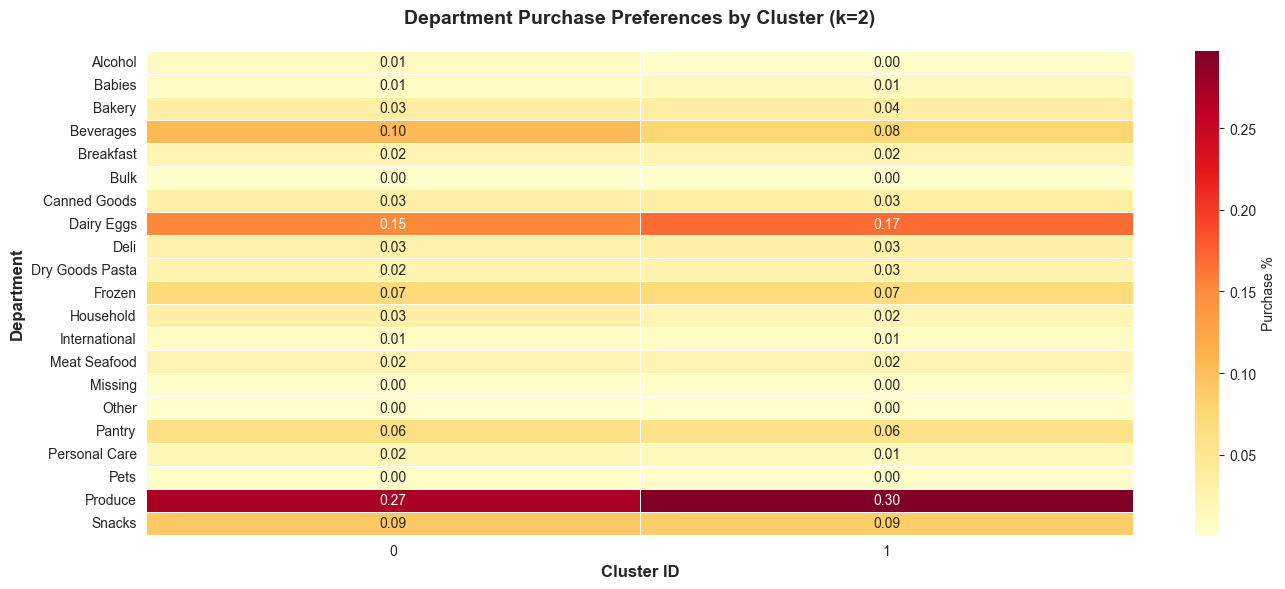


TOP DEPARTMENT PER CLUSTER
Cluster 0: Produce                   (0.27% of purchases)
Cluster 1: Produce                   (0.30% of purchases)


In [10]:
# Extract department features
dept_features = [col for col in feature_columns if col.startswith('dept_pct_')]
dept_names = [col.replace('dept_pct_', '').replace('_', ' ').title() for col in dept_features]

# Get mean department percentages per cluster
dept_profiles = cluster_profiles[dept_features]
dept_profiles.columns = dept_names

# Create heatmap
plt.figure(figsize=(14, max(6, optimal_k * 0.8)))
sns.heatmap(dept_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Purchase %'}, linewidths=0.5)
plt.title(f'Department Purchase Preferences by Cluster (k={optimal_k})', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylabel('Department', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print top department for each cluster
print("\n" + "="*80)
print("TOP DEPARTMENT PER CLUSTER")
print("="*80)
for cluster_id in range(optimal_k):
    top_dept_idx = dept_profiles.iloc[cluster_id].argmax()
    top_dept = dept_profiles.columns[top_dept_idx]
    top_pct = dept_profiles.iloc[cluster_id, top_dept_idx]
    print(f"Cluster {cluster_id}: {top_dept:25s} ({top_pct:.2f}% of purchases)")
print("="*80)

## Save Results

Export the clustered data for further analysis.

In [11]:
# Save clustered results
output_path = r"c:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\8th exploration instacart\instacart_kmeans_clustered.csv"
df_clustered.to_csv(output_path, index=False)

print("="*80)
print("RESULTS SAVED")
print("="*80)
print(f"File: {output_path}")
print(f"Records: {len(df_clustered):,}")
print(f"Columns: {len(df_clustered.columns)} (original features + cluster label)")
print("="*80)

# Summary statistics
print("\nFinal Summary:")
print(f"  Optimal K: {optimal_k}")
print(f"  Silhouette Score: {final_silhouette:.4f}")
print(f"  Inertia: {final_inertia:,.0f}")
print(f"  Users clustered: {len(df_clustered):,}")
print(f"\n✓ K-Means clustering complete!")

RESULTS SAVED
File: c:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\8th exploration instacart\instacart_kmeans_clustered.csv
Records: 206,209
Columns: 38 (original features + cluster label)

Final Summary:
  Optimal K: 2
  Silhouette Score: 0.0944
  Inertia: 6,646,643
  Users clustered: 206,209

✓ K-Means clustering complete!
